In [1]:
import pandas as pd


In [24]:
ridge_selected_10_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/feature_selection/RNAseq/feature_importance_smote_RIDGE_7b_top_genes_elbow_10.csv"
ridge_selected_40_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/feature_selection/RNAseq/feature_importance_smote_RIDGE_7b_top_genes_elbow_40.csv"
catboost_selected_10_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_10.csv'
catboost_selected_40_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_40.csv"
#catboost_selected_10_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_elbow_10.csv"
#catboost_selected_40_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_elbow_40.csv"

In [42]:
ridge_selected_10 = pd.read_csv(ridge_selected_10_path, index_col=0)
ridge_selected_40 = pd.read_csv(ridge_selected_40_path, index_col=0)
catboost_selected_10 = pd.read_csv(catboost_selected_10_path, index_col=0)
catboost_selected_40 = pd.read_csv(catboost_selected_40_path, index_col=0)

ridge_selected_40['Ensembl'] = ridge_selected_40['Symbol']
ridge_selected_40.drop(columns=['Symbol'], inplace=True)
ridge_selected_10['Ensembl'] = ridge_selected_10['Symbol']
ridge_selected_10.drop(columns=['Symbol'], inplace=True)


In [45]:
catboost_selected_10['Ensembl'] = catboost_selected_10.index
catboost_selected_40['Ensembl'] = catboost_selected_40.index
catboost_selected_10['coef'] = catboost_selected_10['importance']
catboost_selected_40['coef'] = catboost_selected_40['importance']
catboost_selected_10['abs_coef'] = catboost_selected_10['coef'].abs()
catboost_selected_40['abs_coef'] = catboost_selected_40['coef'].abs()

catboost_selected_10.reset_index(inplace=True)
catboost_selected_40.reset_index(inplace=True)
catboost_selected_10.drop(columns=['importance', 'index'], inplace=True)
catboost_selected_40.drop(columns=['importance', 'index'], inplace=True)


In [32]:
ridge_selected_40.head()

,Ensembl,coef,abs_coef
63,ENSG00000004848.7,1.272214,1.272214
228,ENSG00000009307.15,1.614391,1.614391
355,ENSG00000015479.18,2.187071,2.187071
409,ENSG00000022267.16,2.043561,2.043561
515,ENSG00000036448.9,0.849731,0.849731


In [47]:
catboost_selected_40.head()

,Ensembl,coef,abs_coef
0,ENSG00000203685.9,19.534839,19.534839
1,ENSG00000066855.15,9.205338,9.205338
2,ENSG00000035664.11,6.349829,6.349829
3,ENSG00000103264.17,4.661575,4.661575
4,ENSG00000164879.6,4.181707,4.181707


In [46]:
catboost_selected_10.head()

,Ensembl,coef,abs_coef
0,ENSG00000262855.1,17.346561,17.346561
1,ENSG00000076685.18,12.762942,12.762942
2,ENSG00000103353.15,12.215974,12.215974
3,ENSG00000285043.1,7.358886,7.358886
4,ENSG00000132475.10,6.822107,6.822107


In [35]:
catboost_selected_10

print("Len ridge_selected_10:", len(ridge_selected_10))
print("Len ridge_selected_40:", len(ridge_selected_40))
print("Len catboost_selected_10:", len(catboost_selected_10))
print("Len catboost_selected_40:", len(catboost_selected_40))

Len ridge_selected_10: 384
Len ridge_selected_40: 345
Len catboost_selected_10: 369
Len catboost_selected_40: 525


In [59]:
ridge_genes_10 = set(ridge_selected_10['Ensembl'])
ridge_genes_40 = set(ridge_selected_40['Ensembl'])
catboost_genes_10 = set(catboost_selected_10['Ensembl'])
catboost_genes_40 = set(catboost_selected_40['Ensembl'])
all_genes = ridge_genes_10.union(ridge_genes_40, catboost_genes_10, catboost_genes_40)
print(len(all_genes))
# for each of the genes in all_genes, check if the gene is in each of the selected sets, creating a dataframe with the genes as rows with a True if exists and a False if not
all_genes_df = pd.DataFrame(index=list(all_genes))
all_genes_df['ridge_selected_10'] = all_genes_df.index.isin(ridge_genes_10)
all_genes_df['ridge_selected_40'] = all_genes_df.index.isin(ridge_genes_40)
all_genes_df['catboost_selected_10'] = all_genes_df.index.isin(catboost_genes_10)
all_genes_df['catboost_selected_40'] = all_genes_df.index.isin(catboost_genes_40)
all_genes_df.reset_index(inplace=True)
all_genes_df.rename(columns={'index': 'Ensembl'}, inplace=True)

1098


In [63]:
all_genes_df.index = all_genes_df['Ensembl']
all_genes_df.drop(columns=['Ensembl'], inplace=True)

In [66]:
all_genes_df.head()

,ridge_selected_10,ridge_selected_40,catboost_selected_10,catboost_selected_40
Ensembl,,,,
ENSG00000109475.16,True,True,False,False
ENSG00000101210.11,False,False,True,True
ENSG00000105373.18,False,False,True,False
ENSG00000167996.15,True,True,False,False
ENSG00000120963.11,False,False,True,True


In [91]:
# show genes that are true in all columns
intersection = all_genes_df[all_genes_df.all(axis=1)].index.tolist()
len(intersection)

21

In [92]:
intersection

['ENSG00000179912.20',
 'ENSG00000164879.6',
 'ENSG00000166710.17',
 'ENSG00000252336.1',
 'ENSG00000164265.8',
 'ENSG00000151327.12',
 'ENSG00000116288.12',
 'ENSG00000107745.18',
 'ENSG00000222346.1',
 'ENSG00000198668.10',
 'ENSG00000205726.14',
 'ENSG00000156298.12',
 'ENSG00000171055.14',
 'ENSG00000237973.1',
 'ENSG00000103145.10',
 'ENSG00000134138.19',
 'ENSG00000234441.1',
 'ENSG00000186591.11',
 'ENSG00000149925.18',
 'ENSG00000126524.9',
 'ENSG00000094755.16']

In [72]:
# make upset plot of the genes selected by each method
import matplotlib.pyplot as plt



In [74]:
from collections import OrderedDict
from upsetplot import generate_counts
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships
from upsetplot import from_contents

X = all_genes_df
subset_df = X
# Assuming X is a dataframe where the index is the gene and columns represent sets
result_subset = {}

# Iterate over columns to extract genes marked as True
for col in subset_df.columns:
    # Filter genes where the column value is True
    genes = subset_df.index[subset_df[col] == True].tolist()
    # Add the list to the dictionary with the column name as the key
    result_subset[col] = genes



ordered_keys = [
    'catboost_selected_10',
    'ridge_selected_10',
    'catboost_selected_40',
    'ridge_selected_40',
    
]

# Create a new OrderedDict following the desired order
result_subset_sorted = OrderedDict((k, result_subset[k]) for k in ordered_keys if k in result_subset)
result_subset = result_subset_sorted
upset_data = from_contents(result_subset_sorted)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


In [79]:
upset_data

id
catboost_selected_10 ridge_selected_10 catboost_selected_40 ridge_selected_40                    
True                 False             True                 False              ENSG00000101210.11
                                       False                False              ENSG00000105373.18
                                       True                 False              ENSG00000120963.11
                                       False                False              ENSG00000173801.16
                                       True                 False              ENSG00000114770.16
...                                                                                           ...
False                False             False                True               ENSG00000104131.12
                                                            True                ENSG00000199373.1
                                                            True               ENSG00000140416.20
                                                            True                ENSG00000145358.6
                                                            True               ENSG00000172403.10

[1098 rows x 1 columns]

The upsetplot library's plot() function accepts the sort_by parameter, which determines how subsets are ordered in the plot. The available values for sort_by are:
upsetplot.readthedocs.io+1upsetplot.readthedocs.io+1

    'cardinality'

    'degree'

    '-cardinality'

    '-degree'

    'input'

    '-input'


Description of sort_by Values

    'cardinality': Sort subsets by the number of elements they contain, from largest to smallest.

    'degree': Sort subsets by the number of categories they intersect, from fewest to most.

    '-cardinality': Sort subsets by cardinality, from smallest to largest.

    '-degree': Sort subsets by degree, from most to fewest.

    'input': Maintain the order of subsets as they appear in the input data.

    '-input': Reverse the order of subsets as they appear in the input data.


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inpla

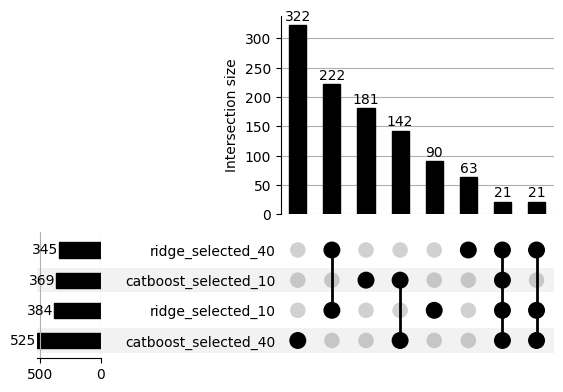

In [96]:
#plot(upset_data, min_subset_size=15, show_counts=True)
# plot without moving the orignial ordering the sets
plot(upset_data, min_subset_size=15, show_counts=True, orientation='horizontal', sort_by='cardinality')
plt.savefig("results/upset_plot_all_selected_genes.svg", format="svg", dpi=600)  # For SVG

In [89]:
from anndata import AnnData
import scanpy as sc
import pickle

# load annot
with open('../Shap_values/annot.pkl', 'rb') as f:
    annot = pickle.load(f)

In [94]:
from convert_ensembl_2_symbol import convert_to_symbol, filter_nameless_genes
ensebl_names = intersection
ensebl_names = filter_nameless_genes(ensebl_names, annot)
symbol_names = convert_to_symbol(ensebl_names, annot)
ensebl_names = pd.Series(ensebl_names)
symbol_names = pd.Series(symbol_names)
symbol_names = symbol_names.fillna(ensebl_names)


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [95]:
symbol_names

0                R3HDM2
1                   CA3
2                   B2M
3             RNA5SP148
4               SCGB3A2
5              FAM177A1
6                 PARK7
7                 MICU1
8             RNA5SP237
9                 CALM1
10                ITSN1
11               TSPAN7
12                 FEZ2
13             MTCO1P12
14              HCFC1R1
15                MEIS2
16    ENSG00000234441.1
17                UBE2H
18                ALDOA
19                 SBDS
20                GABRP
dtype: object